In [5]:
"""
Chart: Cost of Returns Analysis
=================================
Nguồn: returns_master + order_items_master (output từ pipeline)
Yêu cầu: pip install pandas plotly
"""

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# ──────────────────────────────────────────────
# 1. LOAD DỮ LIỆU
# ──────────────────────────────────────────────

returns = pd.read_csv("returns_master.csv", parse_dates=["return_date", "order_date"])
items   = pd.read_csv("order_items_master.csv", parse_dates=["order_date"], low_memory=False)

# Chuẩn hóa kiểu số
returns["refund_amount"]   = pd.to_numeric(returns["refund_amount"],   errors="coerce").fillna(0)
returns["return_quantity"] = pd.to_numeric(returns["return_quantity"], errors="coerce").fillna(0)
items["net_revenue"]       = pd.to_numeric(items["net_revenue"],       errors="coerce").fillna(0)
items["gross_profit"]      = pd.to_numeric(items["gross_profit"],      errors="coerce").fillna(0)

# ──────────────────────────────────────────────
# 2. CHUẨN BỊ DỮ LIỆU
# ──────────────────────────────────────────────

# Tổng revenue & profit từ order_items_master
total_revenue = items["net_revenue"].sum()
total_profit  = items["gross_profit"].sum()
total_refund  = returns["refund_amount"].sum()
total_returns = len(returns)
total_orders  = items["order_id"].nunique()

# ── 2a. Return rate tổng quan ─────────────────
return_rate_revenue = total_refund / total_revenue * 100
return_rate_orders  = total_returns / total_orders * 100

# ── 2b. Theo category ─────────────────────────
# Tổng revenue theo category
rev_by_cat = (
    items.groupby("category")
    .agg(
        total_revenue =("net_revenue",  "sum"),
        total_profit  =("gross_profit", "sum"),
        total_orders  =("order_id",     "nunique"),
    )
    .reset_index()
)

# Tổng refund & return theo category
ret_by_cat = (
    returns.groupby("category")
    .agg(
        refund_amount  =("refund_amount",   "sum"),
        return_quantity=("return_quantity", "sum"),
        return_count   =("return_id",       "count"),
    )
    .reset_index()
)

cat_df = rev_by_cat.merge(ret_by_cat, on="category", how="left").fillna(0)
cat_df["return_rate_rev"]    = cat_df["refund_amount"]   / cat_df["total_revenue"]  * 100
cat_df["return_rate_orders"] = cat_df["return_count"]    / cat_df["total_orders"]   * 100
cat_df["profit_after_return"]= cat_df["total_profit"]    - cat_df["refund_amount"]
cat_df = cat_df.sort_values("return_rate_rev", ascending=False)

# ── 2c. Theo return_reason ────────────────────
if "return_reason" in returns.columns:
    by_reason = (
        returns.groupby("return_reason")
        .agg(
            so_lan       =("return_id",      "count"),
            refund_total =("refund_amount",  "sum"),
            qty_returned =("return_quantity","sum"),
        )
        .reset_index()
        .sort_values("refund_total", ascending=True)  # ascending cho horizontal bar
    )
else:
    by_reason = pd.DataFrame()

# ── 2d. Theo tháng ────────────────────────────
monthly_ret = (
    returns.groupby(returns["return_date"].dt.to_period("M"))
    .agg(
        refund_amount  =("refund_amount",   "sum"),
        return_count   =("return_id",       "count"),
    )
    .reset_index()
)
monthly_ret["return_date"] = monthly_ret["return_date"].dt.to_timestamp()

monthly_rev = (
    items.groupby(items["order_date"].dt.to_period("M"))
    .agg(net_revenue=("net_revenue", "sum"))
    .reset_index()
)
monthly_rev["order_date"] = monthly_rev["order_date"].dt.to_timestamp()

monthly = monthly_rev.merge(
    monthly_ret.rename(columns={"return_date": "order_date"}),
    on="order_date", how="left"
).fillna(0)
monthly["return_rate"] = monthly["refund_amount"] / monthly["net_revenue"] * 100

# ── 2e. Top sản phẩm bị trả nhiều nhất ───────
if "product_name" in returns.columns:
    by_product = (
        returns.groupby(["product_name", "category"])
        .agg(
            return_count  =("return_id",      "count"),
            refund_total  =("refund_amount",  "sum"),
            qty_returned  =("return_quantity","sum"),
        )
        .reset_index()
        .sort_values("refund_total", ascending=False)
        .head(15)
    )
else:
    by_product = pd.DataFrame()

# ──────────────────────────────────────────────
# 3. VẼ BIỂU ĐỒ
# ──────────────────────────────────────────────

COLOR_RETURN  = "#E24B4A"
COLOR_REVENUE = "#378ADD"
COLOR_PROFIT  = "#1D9E75"
COLOR_WARNING = "#EF9F27"
BG   = "#FFFFFF"
GRID = "#F0F0F0"
FONT = "Inter, sans-serif"

fig = make_subplots(
    rows=3, cols=2,
    row_heights=[0.22, 0.40, 0.38],
    vertical_spacing=0.10,
    horizontal_spacing=0.10,
    subplot_titles=(
        "Tong quan: Thieu hut do tra hang",
        "Return Rate (%) theo Category",
        "Return Rate & Refund theo thang",
        "Ly do tra hang pho bien nhat",
        "Top 15 san pham bi tra nhieu nhat (Refund)",
        "Profit truoc vs sau khi tru Refund",
    )
)

# ── Chart 1: KPI tổng quan (waterfall) ────────
fig.add_trace(go.Waterfall(
    orientation="v",
    measure=["absolute", "relative", "relative", "total"],
    x=["Net Revenue", "Gross Profit", "Mat do Refund", "Con lai"],
    y=[
        total_revenue,
        total_profit - total_revenue,   # gross profit delta
        -total_refund,                  # mất đi do refund
        0,
    ],
    text=[
        f"{total_revenue/1e9:.1f}B",
        f"{total_profit/1e9:.1f}B",
        f"-{total_refund/1e9:.2f}B",
        f"{(total_profit-total_refund)/1e9:.1f}B",
    ],
    textposition="outside",
    connector=dict(line=dict(color="#ccc", width=1)),
    increasing=dict(marker=dict(color=COLOR_PROFIT)),
    decreasing=dict(marker=dict(color=COLOR_RETURN)),
    totals=dict(marker=dict(color=COLOR_REVENUE)),
    hovertemplate="%{x}: %{y:,.0f}<extra></extra>",
    showlegend=False,
), row=1, col=1)

# ── Chart 2: Return Rate theo category ────────
rate_colors = [
    COLOR_RETURN  if r >= 15 else
    COLOR_WARNING if r >= 8  else
    COLOR_PROFIT
    for r in cat_df["return_rate_rev"]
]

fig.add_trace(go.Bar(
    x=cat_df["category"],
    y=cat_df["return_rate_rev"],
    name="Return Rate (Revenue)",
    marker_color=rate_colors,
    opacity=0.85,
    text=[f"{v:.1f}%" for v in cat_df["return_rate_rev"]],
    textposition="outside",
    hovertemplate="%{x}<br>Return Rate: %{y:.1f}%<extra></extra>",
    showlegend=False,
), row=1, col=2)

fig.add_hline(
    y=return_rate_revenue, row=1, col=2,
    line_dash="dash", line_color="#888", line_width=1.2,
    annotation_text=f"TB toan cong ty: {return_rate_revenue:.1f}%",
    annotation_font=dict(size=9, color="#666"),
)

# ── Chart 3: Return rate theo tháng ──────────
fig.add_trace(go.Bar(
    x=monthly["order_date"], y=monthly["refund_amount"],
    name="Refund Amount",
    marker_color=COLOR_RETURN,
    opacity=0.6,
    hovertemplate="%{x|%m/%Y}<br>Refund: %{y:,.0f}<extra></extra>",
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=monthly["order_date"], y=monthly["return_rate"],
    name="Return Rate %",
    mode="lines+markers",
    line=dict(color=COLOR_WARNING, width=2),
    marker=dict(size=4),
    hovertemplate="%{x|%m/%Y}<br>Rate: %{y:.1f}%<extra></extra>",
    yaxis="y5",
), row=2, col=1)

# ── Chart 4: Lý do trả hàng ──────────────────
if not by_reason.empty:
    reason_colors = [COLOR_RETURN] * len(by_reason)
    fig.add_trace(go.Bar(
        x=by_reason["refund_total"],
        y=by_reason["return_reason"],
        orientation="h",
        name="Refund theo ly do",
        marker_color=reason_colors,
        opacity=0.8,
        text=[f"{v/1e6:.1f}M" for v in by_reason["refund_total"]],
        textposition="outside",
        hovertemplate="%{y}<br>Refund: %{x:,.0f}<br>So lan: %{customdata}<extra></extra>",
        customdata=by_reason["so_lan"],
        showlegend=False,
    ), row=2, col=2)

# ── Chart 5: Top 15 sản phẩm bị trả ──────────
if not by_product.empty:
    by_product_sorted = by_product.sort_values("refund_total", ascending=True)
    fig.add_trace(go.Bar(
        x=by_product_sorted["refund_total"],
        y=by_product_sorted["product_name"],
        orientation="h",
        name="Top san pham bi tra",
        marker_color=COLOR_RETURN,
        opacity=0.75,
        text=[f"{v/1e6:.1f}M" for v in by_product_sorted["refund_total"]],
        textposition="outside",
        hovertemplate="%{y}<br>Refund: %{x:,.0f}<br>Category: %{customdata}<extra></extra>",
        customdata=by_product_sorted["category"],
        showlegend=False,
    ), row=3, col=1)

# ── Chart 6: Profit trước vs sau khi trừ refund ──
cat_sorted = cat_df.sort_values("total_profit", ascending=False)
fig.add_trace(go.Bar(
    x=cat_sorted["category"],
    y=cat_sorted["total_profit"],
    name="Gross Profit",
    marker_color=COLOR_PROFIT,
    opacity=0.7,
    hovertemplate="%{x}<br>Gross Profit: %{y:,.0f}<extra></extra>",
), row=3, col=2)

fig.add_trace(go.Bar(
    x=cat_sorted["category"],
    y=cat_sorted["profit_after_return"],
    name="Profit sau Refund",
    marker_color=COLOR_REVENUE,
    opacity=0.85,
    hovertemplate="%{x}<br>Profit sau Refund: %{y:,.0f}<extra></extra>",
), row=3, col=2)

# ──────────────────────────────────────────────
# 4. LAYOUT
# ──────────────────────────────────────────────

fig.update_layout(
    title=dict(
        text="Cost of Returns Analysis",
        font=dict(size=18, color="#1a1a1a"),
        x=0.02,
    ),
    height=960,
    plot_bgcolor=BG,
    paper_bgcolor=BG,
    font=dict(family=FONT, size=11, color="#444"),
    hovermode="closest",
    barmode="group",
    legend=dict(
        orientation="h", yanchor="bottom", y=1.01,
        xanchor="right", x=1,
        bgcolor="rgba(0,0,0,0)",
        font=dict(size=11),
    ),
    margin=dict(l=50, r=60, t=80, b=50),
)

for ann in fig.layout.annotations:
    ann.font.size = 12

fig.update_yaxes(gridcolor=GRID, zeroline=False)
fig.update_xaxes(showgrid=False)

fig.update_yaxes(title_text="Gia tri (VND)", tickformat=",.0f", row=1, col=1)
fig.update_yaxes(title_text="Return Rate (%)", ticksuffix="%", row=1, col=2)
fig.update_yaxes(title_text="Refund (VND)",   tickformat=",.0f", row=2, col=1)
fig.update_yaxes(title_text="Refund (VND)",   tickformat=",.0f", row=2, col=2)
fig.update_yaxes(title_text="San pham",        row=3, col=1)
fig.update_yaxes(title_text="Gia tri (VND)",  tickformat=",.0f", row=3, col=2)

fig.update_xaxes(tickangle=-20, row=1, col=2)
fig.update_xaxes(tickformat="%m/%Y", tickangle=-30, row=2, col=1)
fig.update_xaxes(tickangle=-20, row=3, col=2)

# ──────────────────────────────────────────────
# 5. IN BẢNG TÓM TẮT
# ──────────────────────────────────────────────

print("\n===== COST OF RETURNS — TONG QUAN =====")
print(f"  Tong Revenue    : {total_revenue:>18,.0f} VND")
print(f"  Tong Gross Profit: {total_profit:>17,.0f} VND")
print(f"  Tong Refund     : {total_refund:>18,.0f} VND")
print(f"  Return Rate Rev : {return_rate_revenue:>17.2f} %")
print(f"  Return Rate Don : {return_rate_orders:>17.2f} %")
print(f"  Profit sau Refund: {(total_profit-total_refund):>16,.0f} VND")

print("\n===== RETURN RATE THEO CATEGORY =====")
print(cat_df[["category","total_revenue","refund_amount",
              "return_rate_rev","return_count","profit_after_return"]]
      .rename(columns={
          "category":           "Category",
          "total_revenue":      "Revenue",
          "refund_amount":      "Refund",
          "return_rate_rev":    "Rate (%)",
          "return_count":       "So lan tra",
          "profit_after_return":"Profit sau Refund",
      })
      .to_string(index=False, float_format=lambda x: f"{x:,.1f}"))


===== COST OF RETURNS — TONG QUAN =====
  Tong Revenue    :     15,680,869,265 VND
  Tong Gross Profit:     1,517,418,746 VND
  Tong Refund     :        510,598,507 VND
  Return Rate Rev :              3.26 %
  Return Rate Don :              6.17 %
  Profit sau Refund:    1,006,820,240 VND

===== RETURN RATE THEO CATEGORY =====
  Category          Revenue        Refund  Rate (%)  So lan tra  Profit sau Refund
      GenZ    328,710,175.6  11,145,648.2       3.4        2126       39,690,729.3
   Outdoor  2,353,396,796.9  78,717,514.9       3.3       14720      188,316,577.1
Streetwear 12,558,477,099.2 406,708,249.1       3.2       21799      759,099,262.4
    Casual    440,285,193.8  14,027,094.4       3.2        1294       19,713,670.9


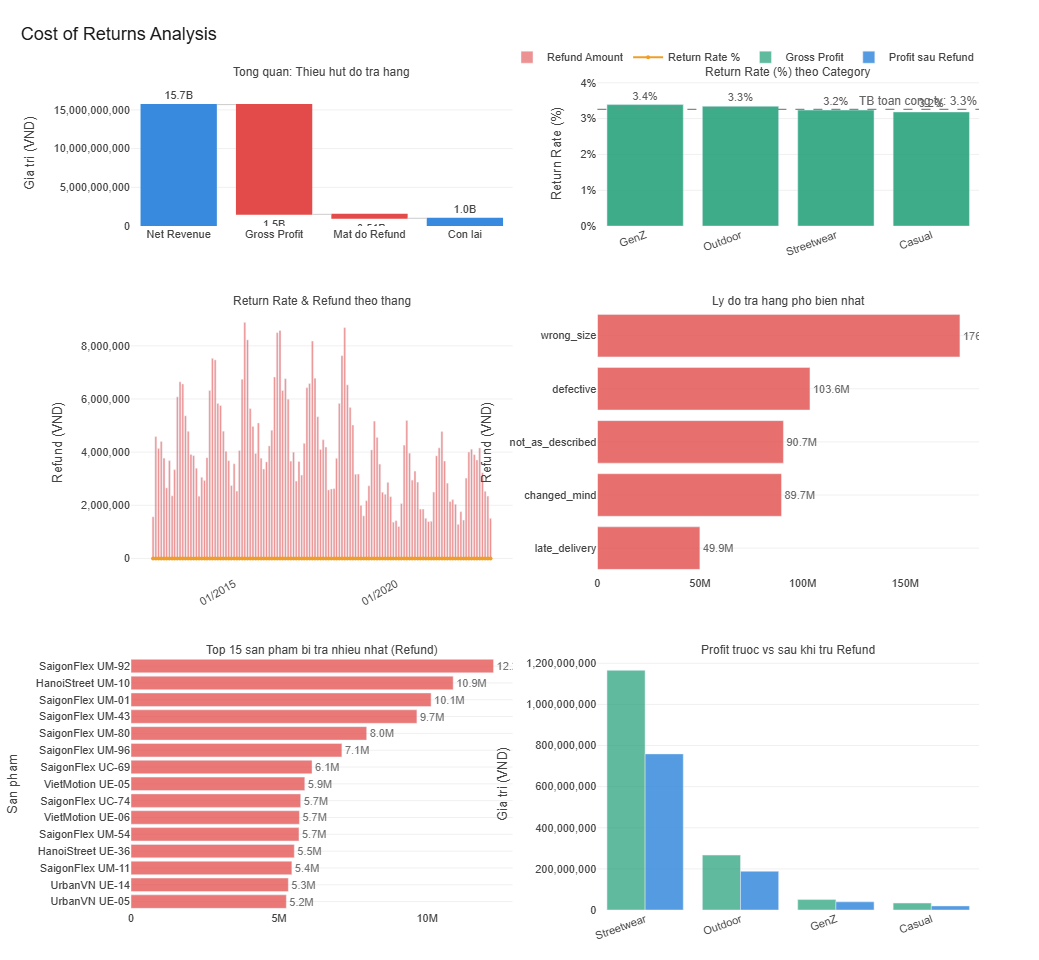

In [6]:
fig.show()

In [8]:
import pandas as pd

df = pd.read_csv("order_items_master.csv", low_memory=False)

# Tính true_gross_margin
df["gross_profit"]      = pd.to_numeric(df["gross_profit"],    errors="coerce")
df["gross_revenue"]     = pd.to_numeric(df["gross_revenue"],   errors="coerce")
df["true_gross_margin"] = df["gross_profit"] / df["gross_revenue"].replace(0, float("nan"))

# Kiểm tra
print(df[["product_name","category","gross_profit","gross_revenue","true_gross_margin"]].head())
print(f"\nSo dong co true_gross_margin hop le: {df['true_gross_margin'].notna().sum():,}")

       product_name    category  gross_profit  gross_revenue  \
0  VietMotion YY-09        GenZ    590.953941        7967.54   
1  SaigonFlex UC-74  Streetwear   8249.820384       71163.75   
2  SaigonFlex UM-01  Streetwear   3387.953233       33660.99   
3  SaigonFlex UC-00  Streetwear   7169.097610       53196.25   
4     UrbanVN RP-10     Outdoor    549.143643        1597.84   

   true_gross_margin  
0           0.074170  
1           0.115927  
2           0.100649  
3           0.134767  
4           0.343679  

So dong co true_gross_margin hop le: 714,669


In [10]:
"""
Chart: Cohort Analysis & Customer LTV
=======================================
Nguồn: orders_master + order_items_master (output từ pipeline)
Yêu cầu: pip install pandas plotly
"""

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# ──────────────────────────────────────────────
# 1. LOAD DỮ LIỆU
# ──────────────────────────────────────────────

orders = pd.read_csv("orders_master.csv", parse_dates=["order_date"])
items  = pd.read_csv("order_items_master.csv", parse_dates=["order_date"])

# Chuẩn hóa kiểu số
items["net_revenue"]   = pd.to_numeric(items["net_revenue"],   errors="coerce").fillna(0)
items["gross_profit"]  = pd.to_numeric(items["gross_profit"],  errors="coerce").fillna(0)
items["discount_amount"] = pd.to_numeric(items["discount_amount"], errors="coerce").fillna(0)
items["cogs_total"]    = pd.to_numeric(items["cogs_total"],    errors="coerce").fillna(0)

# Chỉ lấy đơn delivered
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

# ──────────────────────────────────────────────
# 2. COHORT ANALYSIS
# ──────────────────────────────────────────────

# ── 2a. Xác định cohort month cho mỗi khách ──
# Cohort = tháng đặt đơn đầu tiên
first_order = (
    orders_delivered.groupby("customer_id")["order_date"]
    .min()
    .reset_index()
    .rename(columns={"order_date": "cohort_date"})
)
first_order["cohort_month"] = first_order["cohort_date"].dt.to_period("M")

# Gắn cohort vào orders
orders_cohort = orders_delivered.merge(first_order[["customer_id","cohort_month"]], on="customer_id", how="left")
orders_cohort["order_month"]   = orders_cohort["order_date"].dt.to_period("M")
orders_cohort["period_number"] = (
    orders_cohort["order_month"] - orders_cohort["cohort_month"]
).apply(lambda x: x.n if hasattr(x, "n") else int(x))

# ── 2b. Cohort Retention Rate ─────────────────
cohort_data = (
    orders_cohort.groupby(["cohort_month", "period_number"])["customer_id"]
    .nunique()
    .reset_index()
    .rename(columns={"customer_id": "customers"})
)

cohort_pivot = cohort_data.pivot(index="cohort_month", columns="period_number", values="customers")

# Chỉ lấy 12 tháng đầu (period 0–11)
cohort_pivot = cohort_pivot.loc[:, cohort_pivot.columns <= 11]

# Tính retention rate
cohort_size   = cohort_pivot[0]
retention_pct = cohort_pivot.divide(cohort_size, axis=0) * 100

# Chỉ lấy cohort có đủ dữ liệu (>= 6 tháng theo dõi)
retention_pct = retention_pct.dropna(thresh=6)

# Giới hạn 24 cohort gần nhất để heatmap không bị chật
retention_pct = retention_pct.tail(24)

# Convert index sang string
retention_pct.index = retention_pct.index.astype(str)

# ── 2c. Churn Rate tổng hợp theo period ───────
avg_retention = retention_pct.mean(axis=0)
avg_churn     = 100 - avg_retention

# ──────────────────────────────────────────────
# 3. LTV ANALYSIS
# ──────────────────────────────────────────────

# ── 3a. LTV lịch sử (Historical LTV) ─────────
# LTV = tổng gross_profit của khách xuyên suốt lịch sử
ltv_df = (
    items.groupby("customer_id")
    .agg(
        total_revenue  =("net_revenue",    "sum"),
        total_profit   =("gross_profit",   "sum"),
        total_discount =("discount_amount","sum"),
        total_orders   =("order_id",       "nunique"),
        total_items    =("quantity",       "sum"),
    )
    .reset_index()
)
ltv_df["avg_order_value"] = ltv_df["total_revenue"] / ltv_df["total_orders"]
ltv_df["ltv"] = ltv_df["total_profit"]  # Historical LTV = tổng gross profit

# ── 3b. LTV theo acquisition_channel ──────────
if "cust_acquisition_channel" in orders.columns:
    channel_col = "cust_acquisition_channel"
elif "acquisition_channel" in orders.columns:
    channel_col = "acquisition_channel"
else:
    channel_col = None

if channel_col:
    channel_map = orders[["customer_id", channel_col]].drop_duplicates("customer_id")
    ltv_channel = ltv_df.merge(channel_map, on="customer_id", how="left")
    ltv_by_channel = (
        ltv_channel.groupby(channel_col)
        .agg(
            avg_ltv      =("ltv",          "mean"),
            total_ltv    =("ltv",          "sum"),
            avg_orders   =("total_orders", "mean"),
            customer_count=("customer_id", "nunique"),
        )
        .reset_index()
        .sort_values("avg_ltv", ascending=False)
    )
else:
    ltv_by_channel = pd.DataFrame()

# ── 3c. LTV phân phối (histogram buckets) ─────
ltv_df["ltv_bucket"] = pd.cut(
    ltv_df["ltv"],
    bins=[-float("inf"), 0, 500000, 1000000, 2000000, 5000000, float("inf")],
    labels=["<0 (Lo)", "0-500K", "500K-1M", "1M-2M", "2M-5M", ">5M (VIP)"]
)
ltv_bucket_counts = ltv_df["ltv_bucket"].value_counts().sort_index()

# ── 3d. Cumulative LTV theo số đơn ────────────
ltv_orders = (
    ltv_df.groupby("total_orders")
    .agg(avg_ltv=("ltv", "mean"), customer_count=("customer_id", "count"))
    .reset_index()
    .sort_values("total_orders")
    .head(20)
)

# ──────────────────────────────────────────────
# 4. VẼ BIỂU ĐỒ
# ──────────────────────────────────────────────

COLOR_MAIN    = "#378ADD"
COLOR_PROFIT  = "#1D9E75"
COLOR_WARNING = "#EF9F27"
COLOR_LOSS    = "#E24B4A"
COLOR_PURPLE  = "#7F77DD"
BG   = "#FFFFFF"
GRID = "#F0F0F0"
FONT = "Inter, sans-serif"

fig = make_subplots(
    rows=3, cols=2,
    row_heights=[0.38, 0.32, 0.30],
    vertical_spacing=0.10,
    horizontal_spacing=0.10,
    subplot_titles=(
        "Cohort Retention Rate (%) — 12 thang dau",
        "Churn Rate trung binh theo thang",
        "LTV phan phoi theo nhom khach hang",
        "LTV trung binh theo Acquisition Channel",
        "LTV tang dan theo so don mua",
        "So sanh: Revenue vs Profit vs Discount theo channel",
    )
)

# ── Chart 1: Cohort Heatmap ────────────────────
z_vals    = retention_pct.values.tolist()
x_vals    = [f"Thang {int(c)}" for c in retention_pct.columns]
y_vals    = retention_pct.index.tolist()
text_vals = [
    [f"{v:.0f}%" if not np.isnan(v) else "N/A" for v in row]
    for row in retention_pct.values
]

fig.add_trace(go.Heatmap(
    z=z_vals,
    x=x_vals,
    y=y_vals,
    colorscale=[
        [0.0,  "#E24B4A"],
        [0.3,  "#EF9F27"],
        [0.6,  "#C8E6C9"],
        [1.0,  "#1D9E75"],
    ],
    zmid=50,
    zmin=0, zmax=100,
    colorbar=dict(
        title=dict(text="Retention %", font=dict(size=10)),
        ticksuffix="%",
        thickness=10,
        len=0.30,
        y=0.85,
    ),
    hovertemplate="Cohort: %{y}<br>%{x}<br>Retention: %{z:.1f}%<extra></extra>",
    showlegend=False,
), row=1, col=1)

# ── Chart 2: Churn Rate theo period ───────────
churn_colors = [
    COLOR_LOSS    if v >= 50 else
    COLOR_WARNING if v >= 30 else
    COLOR_PROFIT
    for v in avg_churn.values
]

fig.add_trace(go.Bar(
    x=x_vals[:len(avg_churn)],
    y=avg_churn.values,
    name="Churn Rate TB",
    marker_color=churn_colors,
    opacity=0.8,
    text=[f"{v:.1f}%" for v in avg_churn.values],
    textposition="outside",
    hovertemplate="%{x}<br>Churn: %{y:.1f}%<extra></extra>",
    showlegend=False,
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=x_vals[:len(avg_retention)],
    y=avg_retention.values,
    name="Retention TB",
    mode="lines+markers",
    line=dict(color=COLOR_PROFIT, width=2),
    marker=dict(size=5),
    hovertemplate="%{x}<br>Retention: %{y:.1f}%<extra></extra>",
), row=1, col=2)

# ── Chart 3: LTV bucket phân phối ─────────────
bucket_colors = [
    COLOR_LOSS, COLOR_WARNING, COLOR_MAIN,
    COLOR_PROFIT, COLOR_PURPLE, "#BA7517"
]

fig.add_trace(go.Bar(
    x=ltv_bucket_counts.index.astype(str),
    y=ltv_bucket_counts.values,
    name="So khach",
    marker_color=bucket_colors[:len(ltv_bucket_counts)],
    opacity=0.8,
    text=[f"{v:,}" for v in ltv_bucket_counts.values],
    textposition="outside",
    hovertemplate="%{x}<br>So khach: %{y:,}<extra></extra>",
    showlegend=False,
), row=2, col=1)

# ── Chart 4: LTV theo channel ─────────────────
if not ltv_by_channel.empty:
    ch_col = ltv_by_channel.columns[0]
    bar_colors = [COLOR_MAIN, COLOR_PROFIT, COLOR_WARNING, COLOR_PURPLE, COLOR_LOSS]

    fig.add_trace(go.Bar(
        x=ltv_by_channel[ch_col],
        y=ltv_by_channel["avg_ltv"],
        name="Avg LTV",
        marker_color=bar_colors[:len(ltv_by_channel)],
        opacity=0.8,
        text=[f"{v/1e3:.0f}K" for v in ltv_by_channel["avg_ltv"]],
        textposition="outside",
        hovertemplate="%{x}<br>Avg LTV: %{y:,.0f}<extra></extra>",
        showlegend=False,
    ), row=2, col=2)

    # Annotation: số khách mỗi channel
    for i, row_d in ltv_by_channel.iterrows():
        fig.add_annotation(
            x=row_d[ch_col],
            y=row_d["avg_ltv"] * 0.5,
            text=f"n={row_d['customer_count']:,}",
            showarrow=False,
            font=dict(size=9, color="white"),
            row=2, col=2,
        )

# ── Chart 5: LTV tăng dần theo số đơn ─────────
fig.add_trace(go.Scatter(
    x=ltv_orders["total_orders"],
    y=ltv_orders["avg_ltv"],
    name="Avg LTV theo so don",
    mode="lines+markers",
    line=dict(color=COLOR_MAIN, width=2.5),
    marker=dict(
        size=ltv_orders["customer_count"].apply(lambda x: max(6, min(20, x/50))),
        color=COLOR_MAIN, opacity=0.7,
    ),
    hovertemplate=(
        "So don: %{x}<br>"
        "Avg LTV: %{y:,.0f}<br>"
        "<extra></extra>"
    ),
    showlegend=False,
), row=3, col=1)

# Đường 0
fig.add_hline(y=0, row=3, col=1, line_color="#ddd", line_width=1)

# ── Chart 6: Revenue vs Profit vs Discount theo channel ──
if not ltv_by_channel.empty:
    ch_col = ltv_by_channel.columns[0]

    # Tính thêm revenue & discount theo channel
    if channel_col:
        channel_summary = (
            ltv_channel.groupby(channel_col)
            .agg(
                total_revenue  =("total_revenue",  "sum"),
                total_profit   =("total_profit",   "sum"),
                total_discount =("total_discount", "sum"),
            )
            .reset_index()
            .sort_values("total_revenue", ascending=False)
        )

        fig.add_trace(go.Bar(
            x=channel_summary[channel_col],
            y=channel_summary["total_revenue"],
            name="Total Revenue",
            marker_color=COLOR_MAIN, opacity=0.6,
            hovertemplate="%{x}<br>Revenue: %{y:,.0f}<extra></extra>",
        ), row=3, col=2)

        fig.add_trace(go.Bar(
            x=channel_summary[channel_col],
            y=channel_summary["total_profit"],
            name="Total Profit",
            marker_color=COLOR_PROFIT, opacity=0.8,
            hovertemplate="%{x}<br>Profit: %{y:,.0f}<extra></extra>",
        ), row=3, col=2)

        fig.add_trace(go.Bar(
            x=channel_summary[channel_col],
            y=channel_summary["total_discount"],
            name="Total Discount",
            marker_color=COLOR_LOSS, opacity=0.7,
            hovertemplate="%{x}<br>Discount: %{y:,.0f}<extra></extra>",
        ), row=3, col=2)

# ──────────────────────────────────────────────
# 5. LAYOUT
# ──────────────────────────────────────────────

fig.update_layout(
    title=dict(
        text="Cohort Analysis & Customer LTV",
        font=dict(size=18, color="#1a1a1a"),
        x=0.02,
    ),
    height=960,
    plot_bgcolor=BG,
    paper_bgcolor=BG,
    font=dict(family=FONT, size=11, color="#444"),
    hovermode="closest",
    barmode="group",
    legend=dict(
        orientation="h", yanchor="bottom", y=1.01,
        xanchor="right", x=1,
        bgcolor="rgba(0,0,0,0)",
        font=dict(size=11),
    ),
    margin=dict(l=50, r=60, t=80, b=50),
)

for ann in fig.layout.annotations:
    ann.font.size = 12

fig.update_yaxes(gridcolor=GRID, zeroline=False)
fig.update_xaxes(showgrid=False)

fig.update_yaxes(title_text="Cohort (thang)",    row=1, col=1)
fig.update_yaxes(title_text="Ti le (%)", ticksuffix="%", row=1, col=2)
fig.update_yaxes(title_text="So khach hang",     tickformat=",", row=2, col=1)
fig.update_yaxes(title_text="Avg LTV (VND)",     tickformat=",.0f", row=2, col=2)
fig.update_yaxes(title_text="Avg LTV (VND)",     tickformat=",.0f", row=3, col=1)
fig.update_yaxes(title_text="Gia tri (VND)",     tickformat=",.0f", row=3, col=2)

fig.update_xaxes(title_text="Thang sau lan mua dau", row=1, col=1)
fig.update_xaxes(title_text="Thang sau lan mua dau", row=1, col=2)
fig.update_xaxes(title_text="Nhom LTV",  row=2, col=1)
fig.update_xaxes(title_text="Channel",  tickangle=-15, row=2, col=2)
fig.update_xaxes(title_text="So don da mua", row=3, col=1)
fig.update_xaxes(title_text="Channel",  tickangle=-15, row=3, col=2)

# ──────────────────────────────────────────────
# 6. IN BẢNG TÓM TẮT
# ──────────────────────────────────────────────

print("\n===== COHORT RETENTION — TRUNG BINH =====")
retention_summary = pd.DataFrame({
    "Period":    x_vals[:len(avg_retention)],
    "Retention": avg_retention.round(1).values,
    "Churn":     avg_churn.round(1).values,
})
print(retention_summary.to_string(index=False))

print("\n===== LTV TONG QUAN =====")
print(f"  Avg LTV toan he thong : {ltv_df['ltv'].mean():>15,.0f} VND")
print(f"  Median LTV            : {ltv_df['ltv'].median():>15,.0f} VND")
print(f"  LTV cao nhat (VIP)    : {ltv_df['ltv'].max():>15,.0f} VND")
print(f"  % khach LTV am (lo)   : {(ltv_df['ltv'] < 0).mean()*100:>14.1f} %")

if not ltv_by_channel.empty:
    print("\n===== LTV THEO ACQUISITION CHANNEL =====")
    print(ltv_by_channel.rename(columns={
        ltv_by_channel.columns[0]: "Channel",
        "avg_ltv":        "Avg LTV",
        "total_ltv":      "Total LTV",
        "avg_orders":     "Avg Orders",
        "customer_count": "So khach",
    }).to_string(index=False, float_format=lambda x: f"{x:,.1f}"))


C:\Users\quocb\AppData\Local\Temp\ipykernel_13156\1984204018.py:19: DtypeWarning: Columns (5,6,23,24,26,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  items  = pd.read_csv("order_items_master.csv", parse_dates=["order_date"])



===== COHORT RETENTION — TRUNG BINH =====
  Period  Retention  Churn
 Thang 0      100.0    0.0
 Thang 1        1.1   98.9
 Thang 2        1.0   99.0
 Thang 3        0.9   99.1
 Thang 4        0.8   99.2
 Thang 5        1.1   98.9
 Thang 6        1.1   98.9
 Thang 7        1.4   98.6
 Thang 8        1.1   98.9
 Thang 9        1.3   98.7
Thang 10        1.5   98.5
Thang 11        1.2   98.8

===== LTV TONG QUAN =====
  Avg LTV toan he thong :          16,814 VND
  Median LTV            :           7,379 VND
  LTV cao nhat (VIP)    :         538,312 VND
  % khach LTV am (lo)   :           21.2 %

===== LTV THEO ACQUISITION CHANNEL =====
       Channel  Avg LTV     Total LTV  Avg Orders  So khach
  social_media 17,272.6 310,941,979.1         7.2     18002
   paid_search 16,992.8 305,853,230.2         7.2     17999
organic_search 16,745.1 451,280,147.5         7.2     26950
email_campaign 16,734.7 182,173,411.7         7.1     10886
        direct 16,304.2 119,623,911.8         7.1      7

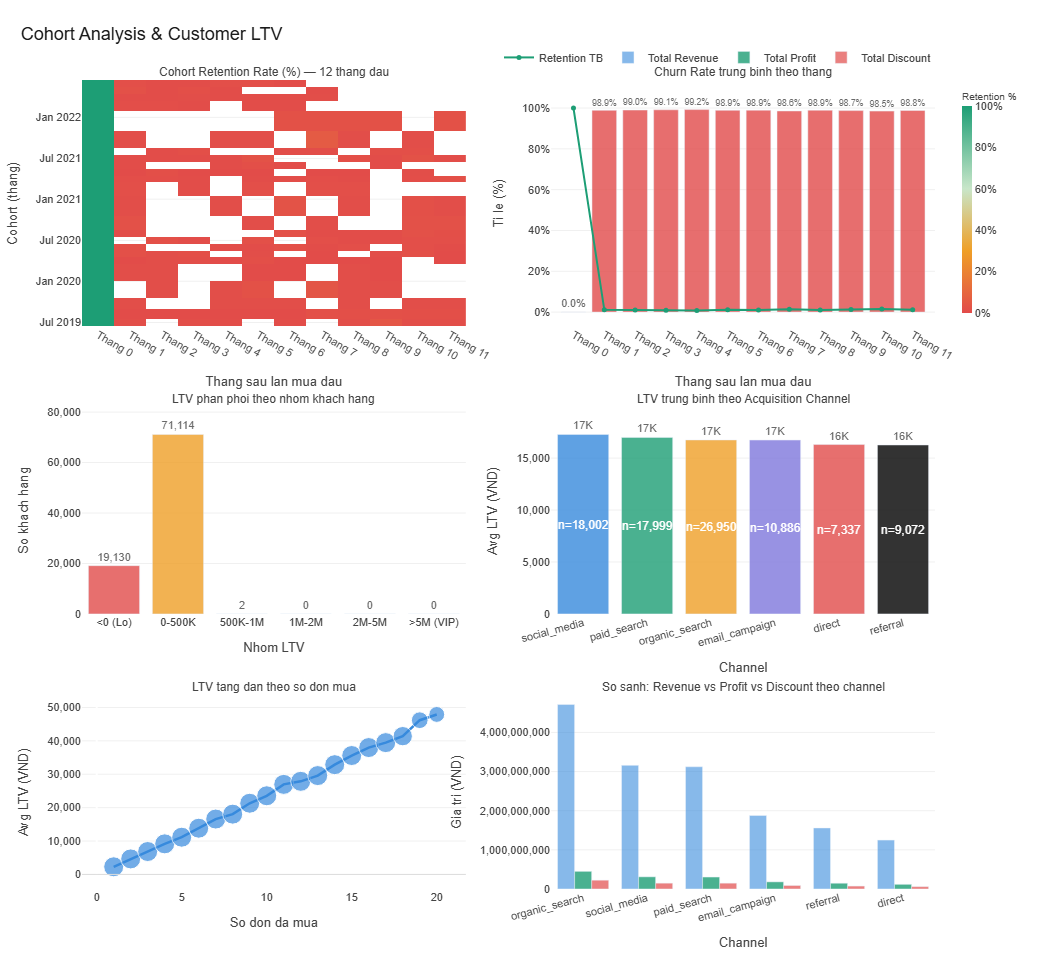

In [11]:
fig.show()